In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from transformers import AdamW, get_scheduler


import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
nltk.download('stopwords')
nltk.download('rslp')


c:\Users\86155\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\86155\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\86155\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

# Reading Data

In [2]:
olist_customer = pd.read_csv('olist_customers_dataset.csv')
olist_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
olist_orders = pd.read_csv('olist_orders_dataset.csv')
olist_order_items = pd.read_csv('olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv('olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
olist_products = pd.read_csv('olist_products_dataset.csv')
olist_sellers = pd.read_csv('olist_sellers_dataset.csv')

In [3]:
# Collections for each dataset
datasets = [olist_customer, olist_geolocation, olist_orders, olist_order_items, olist_order_payments,
            olist_order_reviews, olist_products, olist_sellers]
names = ['olist_customer', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments',
         'olist_order_reviews', 'olist_products', 'olist_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,olist_customer,99441,5,0,0,
1,olist_geolocation,1000163,5,0,0,
2,olist_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,olist_order_items,112650,7,0,0,
4,olist_order_payments,103886,5,0,0,
5,olist_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,olist_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,olist_sellers,3095,4,0,0,


In [4]:
df_overview_list = []
name_col = []

for name, df in zip(names, datasets):
    for col in df.columns:
        num_nulls = df[col].isnull().sum()  # 缺失值数量
        percent_null = (num_nulls / len(df)) * 100  # 缺失值占比
        dtype = df[col].dtype  # 数据类型
        num_unique_categories = df[col].nunique() if df[col].dtype == 'object' else 0  # 类别数量

        df_overview_list.append([name, col, num_nulls, percent_null, dtype, num_unique_categories])
        
df_overview = pd.DataFrame(df_overview_list, columns=['dataset_name', 'feature', 'num_nulls', 'percent_null', 'dtype', 'num_unique_categories'])
df_overview

,dataset_name,feature,num_nulls,percent_null,dtype,num_unique_categories
0,olist_customer,customer_id,0,0.000000,object,99441
1,olist_customer,customer_unique_id,0,0.000000,object,96096
2,olist_customer,customer_zip_code_prefix,0,0.000000,int64,0
3,olist_customer,customer_city,0,0.000000,object,4119
4,olist_customer,customer_state,0,0.000000,object,27
5,olist_geolocation,geolocation_zip_code_prefix,0,0.000000,int64,0
6,olist_geolocation,geolocation_lat,0,0.000000,float64,0
7,olist_geolocation,geolocation_lng,0,0.000000,float64,0
8,olist_geolocation,geolocation_city,0,0.000000,object,8011
9,olist_geolocation,geolocation_state,0,0.000000,object,27


# Natural Language Processing

In [5]:
df_comments = olist_order_reviews.loc[:, ['review_score', 'review_comment_message']]
df_comments = df_comments.dropna(subset=['review_comment_message'])
df_comments = df_comments.reset_index(drop=True)
print(f'Dataset shape: {df_comments.shape}')
df_comments.columns = ['score', 'comment']
df_comments.head()

Dataset shape: (40977, 2)


,score,comment
0,5,Recebi bem antes do prazo estipulado.
1,5,Parabéns lojas lannister adorei comprar pela I...
2,4,aparelho eficiente. no site a marca do aparelh...
3,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,5,"Vendedor confiável, produto ok e entrega antes..."


去除换行符，替换为空格

In [6]:
def re_linebreak(text_list):
    return [re.sub('[\n\r]', ' ', r) for r in text_list]

In [7]:
reviews = list(df_comments['comment'].values)
reviews_linebreak = re_linebreak(reviews)
df_comments['re_linebreak'] = reviews_linebreak
print(reviews[48])
print(reviews_linebreak[48])

Estava faltando apenas um produto, eu recebi hoje , muito obrigada!
Tudo certo!

Att 

Elenice.
Estava faltando apenas um produto, eu recebi hoje , muito obrigada!  Tudo certo!    Att     Elenice.


去除URL，替换为' link '

In [8]:
def re_hyperlinks(text_list):
    pattern = 'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return [re.sub(pattern, ' link ', r) for r in text_list]

In [9]:
reviews_hyperlinks = re_hyperlinks(reviews_linebreak)
df_comments['re_hyperlinks'] = reviews_hyperlinks
print(reviews_linebreak[10607])
print(reviews_hyperlinks[10607])

comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto http://prntscr.com/jkx7hr quando o produto chegou aqui veio todos com a mesma cor, tabaco http://prntscr.com/
comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto  link  quando o produto chegou aqui veio todos com a mesma cor, tabaco  link 


日期替换为' data '

In [10]:
def re_dates(text_list):
    pattern = '([0-2][0-9]|(3)[0-1])(\/|\.)(((0)[0-9])|((1)[0-2]))(\/|\.)\d{2,4}'
    return [re.sub(pattern, ' data ', r) for r in text_list]

In [11]:
reviews_dates = re_dates(reviews_hyperlinks)
df_comments['re_dates'] = reviews_dates
print(reviews_hyperlinks[567])
print(reviews_dates[567])

ENTREGA MUITO DEMORADA, COMPREI EM 26/03/2018 E ATÉ AGORA NÃO RECEBI OS PRODUTOS
ENTREGA MUITO DEMORADA, COMPREI EM  data  E ATÉ AGORA NÃO RECEBI OS PRODUTOS


钱替换为' dinheiro '

In [12]:
def re_money(text_list):
    pattern = '[R]{0,1}\$[ ]{0,}\d+(,|\.)\d+'
    return [re.sub(pattern, ' dinheiro ', r) for r in text_list]

In [13]:
reviews_money = re_money(reviews_dates)
print(reviews_dates[45])
print(reviews_money[45])

Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un - R$ 25,00 cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un - R$ 35,90 (ESTE FOI ENTREG
Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un -  dinheiro  (ESTE FOI ENTREG


数字替换为' numero '

In [14]:
def re_numbers(text_list):
    return [re.sub('[0-9]+', ' numero ', r) for r in text_list]

In [15]:
reviews_numbers = re_numbers(reviews_money)
df_comments['re_numbers'] = reviews_numbers
print(reviews_money[45])
print(reviews_numbers[45])

Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un -  dinheiro  (ESTE FOI ENTREG
Este foi o pedido  Balde Com  numero  Peças - Blocos De Montar  numero  un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras  numero  Peças Crianças  numero  un -  dinheiro  (ESTE FOI ENTREG


否定词替换为' negação '

In [16]:
def re_negation(text_list):
    return [re.sub('([nN][ãÃaA][oO]|[ñÑ]| [nN] )', ' negação ', r) for r in text_list]

In [17]:
reviews_negation = re_negation(reviews_numbers)
df_comments['re_negation'] = reviews_negation
print(reviews_numbers[11])
print(reviews_negation[11])

Não gostei ! Comprei gato por lebre
 negação  gostei ! Comprei gato por lebre


特殊字符替换为空格

In [18]:
def re_special_chars(text_list):
    return [re.sub('\W', ' ', r) for r in text_list]

In [19]:
reviews_special_chars = re_special_chars(reviews_negation)
df_comments['re_special_chars'] = reviews_special_chars
print(reviews_negation[133])
print(reviews_special_chars[133])

Cada vez que compro mais fico satisfeita parabéns pela honestidade com seus clientes 👏👏👏👏?
Cada vez que compro mais fico satisfeita parabéns pela honestidade com seus clientes      


去除多余空格

In [20]:
def re_whitespaces(text_list):
    white_spaces = [re.sub('\s+', ' ', r) for r in text_list]
    white_spaces_end = [re.sub('[ \t]+$', '', r) for r in white_spaces]
    return white_spaces_end

In [21]:
reviews_whitespaces = re_whitespaces(reviews_special_chars)
df_comments['re_whitespaces'] = reviews_whitespaces
print(reviews_special_chars[3])
print(reviews_whitespaces[3])

Mas um pouco  travando   pelo valor ta Boa   
Mas um pouco travando pelo valor ta Boa


In [22]:
df_comments['score'] = df_comments['score'].astype(int)

# 使用 `re_whitespaces` 作为训练文本
if 're_whitespaces' in df_comments.columns:
    df_comments['text'] = df_comments['re_whitespaces']

score_map = {
    1: 'negative',
    2: 'negative',
    3: 'negative',
    4: 'positive',
    5: 'positive'
}
score = df_comments['score'].map(score_map)
y = score.apply(lambda x: 1 if x == 'positive' else 0).values
# 划分数据集（80% 训练，10% 验证，10% 测试）
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_comments['text'].tolist(), y, test_size=0.2, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    test_texts, test_labels, test_size=0.5, random_state=42
)

In [23]:
# 加载 BERT 预训练模型的 tokenizer
tokenizer = BertTokenizer.from_pretrained("./bert_model/")

# Tokenize 数据，输出 input_ids 和 attention_mask 供 BERT 使用
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

In [24]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# 创建 PyTorch Dataset
train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [25]:
batch_sizes = [16, 32]
learning_rates = [5e-5, 3e-5, 2e-5]
num_epochs_list = [5]

# 生成所有超参数组合
param_grid = list(itertools.product(batch_sizes, learning_rates, num_epochs_list))
best_val_acc = 0
best_params = None
best_model = None

def train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs):
    best_val_loss = float("inf")
    patience_counter = 0
    patience = 3  # Early Stopping 的 patience

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_preds, all_labels = [], []

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()

            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            labels = batch["labels"].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

        avg_train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)

        # 评估验证集
        val_acc, val_loss, _, _ = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}")
        print(f"Validation Loss = {val_loss:.4f}, Validation Acc = {val_acc:.4f}")

        # Early Stopping 逻辑
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    return val_acc


# 评估函数
def evaluate(model, data_loader):
    model.eval()
    predictions, true_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()

            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            labels = batch["labels"].cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(labels)

    avg_val_loss = total_loss / len(data_loader)
    acc = accuracy_score(true_labels, predictions)
    report = classification_report(true_labels, predictions, target_names=["0", "1"])
    return acc, avg_val_loss, true_labels, predictions

In [56]:
print(f"\n Training with batch_size=16, learning_rate=1e-05, num_epochs=5")

# 重新创建 BERT 模型
config = BertConfig.from_pretrained("./bert_model/", num_labels=2, hidden_dropout_prob=0.3)
model = BertForSequenceClassification.from_pretrained("./bert_model/", config=config)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# 重新创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 重新定义优化器和调度器
optimizer = AdamW(model.parameters(), lr=1e-05)
num_training_steps = len(train_loader) * 5
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# 训练模型
val_acc = train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs=5)


 Training with batch_size=16, learning_rate=1e-05, num_epochs=5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss = 0.2866, Train Acc = 0.8898
Validation Loss = 0.2715, Validation Acc = 0.9048
Epoch 2: Train Loss = 0.2351, Train Acc = 0.9143
Validation Loss = 0.2610, Validation Acc = 0.9034
Epoch 3: Train Loss = 0.2203, Train Acc = 0.9209
Validation Loss = 0.2782, Validation Acc = 0.9073
Epoch 4: Train Loss = 0.2096, Train Acc = 0.9250
Validation Loss = 0.2729, Validation Acc = 0.9046
Epoch 5: Train Loss = 0.2018, Train Acc = 0.9278
Validation Loss = 0.2788, Validation Acc = 0.9051
Early stopping triggered!


In [26]:
# 遍历所有超参数组合
for batch_size, lr, num_epochs in param_grid:
    print(f"\n Training with batch_size={batch_size}, learning_rate={lr}, num_epochs={num_epochs}")

    # 重新创建 BERT 模型
    config = BertConfig.from_pretrained("./bert_model/", num_labels=2, hidden_dropout_prob=0.3)
    model = BertForSequenceClassification.from_pretrained("./bert_model/", config=config)
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)
    
    # 重新创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 重新定义优化器和调度器
    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = len(train_loader) * num_epochs
    lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

    # 训练模型
    val_acc = train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs=num_epochs)

    # 记录最佳超参数
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {"batch_size": batch_size, "learning_rate": lr, "num_epochs": num_epochs}
        best_model = model

print("\n Best Hyperparameters:", best_params)
print(f" Best Validation Accuracy: {best_val_acc:.4f}")

# 用最佳模型在测试集上评估
if best_model:
    print("\n Evaluating on Test Set with Best Model...")
    test_acc, test_report, test_true, test_pred = evaluate(best_model, test_loader)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(test_report)


 Training with batch_size=16, learning_rate=5e-05, num_epochs=5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed 

Epoch 1: Train Loss = 0.2729, Train Acc = 0.8986
Validation Loss = 0.2768, Validation Acc = 0.8980
Epoch 2: Train Loss = 0.2319, Train Acc = 0.9176
Validation Loss = 0.2808, Validation Acc = 0.9031
Epoch 3: Train Loss = 0.2069, Train Acc = 0.9267
Validation Loss = 0.2732, Validation Acc = 0.9026
Epoch 4: Train Loss = 0.1809, Train Acc = 0.9375
Validation Loss = 0.3052, Validation Acc = 0.9070
Epoch 5: Train Loss = 0.1570, Train Acc = 0.9480
Validation Loss = 0.3067, Validation Acc = 0.9058

 Training with batch_size=16, learning_rate=3e-05, num_epochs=5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1: Train Loss = 0.3131, Train Acc = 0.8770
Validation Loss = 0.2830, Validation Acc = 0.8982
Epoch 2: Train Loss = 0.2369, Train Acc = 0.9137
Validation Loss = 0.2620, Validation Acc = 0.9036
Epoch 3: Train Loss = 0.2202, Train Acc = 0.9205
Validation Loss = 0.2765, Validation Acc = 0.9046
Epoch 4: Train Loss = 0.1952, Train Acc = 0.9305
Validation Loss = 0.2875, Validation Acc = 0.9068
Epoch 5: Train Loss = 0.1804, Train Acc = 0.9380
Validation Loss = 0.2824, Validation Acc = 0.9107
Early stopping triggered!

 Training with batch_size=16, learning_rate=2e-05, num_epochs=5


...

Epoch 1: Train Loss = 0.2729, Train Acc = 0.8960
Validation Loss = 0.2601, Validation Acc = 0.9029
Epoch 2: Train Loss = 0.2304, Train Acc = 0.9167
Validation Loss = 0.2701, Validation Acc = 0.9053
Epoch 3: Train Loss = 0.2070, Train Acc = 0.9272
Validation Loss = 0.2684, Validation Acc = 0.9073
Epoch 4: Train Loss = 0.1850, Train Acc = 0.9357
Validation Loss = 0.2821, Validation Acc = 0.9065
Early stopping triggered!

 Training with batch_size=32, learning_rate=3e-05, num_epochs=5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1: Train Loss = 0.2754, Train Acc = 0.8981
Validation Loss = 0.2656, Validation Acc = 0.9043
Epoch 2: Train Loss = 0.2306, Train Acc = 0.9165
Validation Loss = 0.2536, Validation Acc = 0.9034
Epoch 3: Train Loss = 0.2125, Train Acc = 0.9251
Validation Loss = 0.2791, Validation Acc = 0.9070
Epoch 4: Train Loss = 0.1940, Train Acc = 0.9319
Validation Loss = 0.2744, Validation Acc = 0.9080
Epoch 5: Train Loss = 0.1800, Train Acc = 0.9376
Validation Loss = 0.2811, Validation Acc = 0.9070
Early stopping triggered!

 Training with batch_size=32, learning_rate=2e-05, num_epochs=5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1: Train Loss = 0.2796, Train Acc = 0.8925
Validation Loss = 0.2642, Validation Acc = 0.9056
Epoch 2: Train Loss = 0.2322, Train Acc = 0.9160
Validation Loss = 0.2655, Validation Acc = 0.9051
Epoch 3: Train Loss = 0.2144, Train Acc = 0.9228
Validation Loss = 0.2676, Validation Acc = 0.9021
Epoch 4: Train Loss = 0.2019, Train Acc = 0.9279
Validation Loss = 0.2830, Validation Acc = 0.9082
Early stopping triggered!

 Best Hyperparameters: {'batch_size': 16, 'learning_rate': 3e-05, 'num_epochs': 5}
 Best Validation Accuracy: 0.9107

 Evaluating on Test Set with Best Model...
Test Accuracy: 0.9122
0.2691505785396164


In [27]:
print(f"\n Training with batch_size=16, learning_rate=2e-05, num_epochs=3")

# 重新创建 BERT 模型
config = BertConfig.from_pretrained("./bert_model/", num_labels=2, hidden_dropout_prob=0.3)
model = BertForSequenceClassification.from_pretrained("./bert_model/", config=config)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# 重新创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 重新定义优化器和调度器
optimizer = AdamW(model.parameters(), lr=2e-05)
num_training_steps = len(train_loader) * 3
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# 训练模型
val_acc = train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs=3)


print("\n Best Hyperparameters:", best_params)
print(f" Best Validation Accuracy: {best_val_acc:.4f}")

# 用最佳模型在测试集上评估

print("\n Evaluating on Test Set with Best Model...")
test_acc, test_report, test_true, test_pred = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")
print(test_report)


 Training with batch_size=16, learning_rate=2e-05, num_epochs=3


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1: Train Loss = 0.2676, Train Acc = 0.8992
Validation Loss = 0.2801, Validation Acc = 0.9026
Epoch 2: Train Loss = 0.2264, Train Acc = 0.9180
Validation Loss = 0.2590, Validation Acc = 0.9073
Epoch 3: Train Loss = 0.2054, Train Acc = 0.9258
Validation Loss = 0.2669, Validation Acc = 0.9080

 Best Hyperparameters: {'batch_size': 16, 'learning_rate': 3e-05, 'num_epochs': 5}
 Best Validation Accuracy: 0.9107

 Evaluating on Test Set with Best Model...
Test Accuracy: 0.9126
0.24777731340711914


In [29]:
torch.save(model.state_dict(), "best_model.pt")
model.load_state_dict(torch.load("best_model.pt"))  # 加载最优模型
test_acc, report, _, _ = evaluate(model, test_loader)
print("✅ Test Accuracy:", test_acc)
print(report)

# 保存 test_texts
import joblib
joblib.dump(test_texts, "test_texts.pkl")

/tmp/ipykernel_3815210/454026041.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))  # 加载最优模型


✅ Test Accuracy: 0.9126403123474865
0.24777731340711914


['test_texts.pkl']

 Macro Accuracy: 0.9024



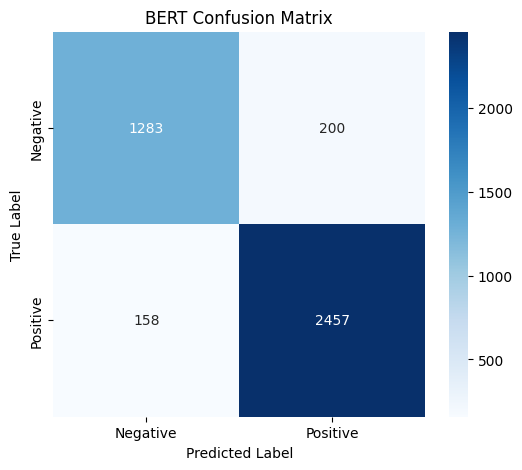

In [28]:
labels = ["Negative", "Positive"]
bert_cm = confusion_matrix(test_true, test_pred)  # BERT模型的真实值和预测值
# 计算每个类别的 accuracy
class_accuracies = []
for i in range(len(bert_cm)):
    TP = bert_cm[i, i]  # 该类别的正确预测数量
    FN = np.sum(bert_cm[i, :]) - TP

    class_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0
    class_accuracies.append(class_accuracy)

# 计算 macro accuracy
macro_accuracy = np.mean(class_accuracies)
print(f" Macro Accuracy: {macro_accuracy:.4f}\n")

plt.figure(figsize=(6,5))
sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BERT Confusion Matrix')
plt.show()